<a href="https://www.kaggle.com/code/ameythakur20/tpu-flower-classification-advanced-ensemble" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Petals to the Metal: Advanced TPU Classification Architecture

**Ensemble of EfficientNet and DenseNet with Stochastic Regularization**

**Author:** [Amey Thakur](https://www.kaggle.com/ameythakur20)

The primary objective of this architecture is to maximize the macro F1 score across 104 highly imbalanced botanical classes. Standard single-model architectures frequently fail to capture the minute morphological differences between sub-species. This pipeline implements a robust, dual-stream ensemble, synthesizing the spatial efficiency of EfficientNet with the dense feature propagation of DenseNet. 

To counteract overfitting on the limited and imbalanced training distribution, the pipeline integrates non-linear learning rate scheduling, Test Time Augmentation (TTA), and advanced stochastic regularization techniques. Every engineering decision is mathematically documented to ensure scholarly transparency and reproducibility.

**Outline:**

1. [Execution Environment Initialization](#1.-Execution-Environment-Initialization)
2. [Hardware Synchronization and Distribution Strategy](#2.-Hardware-Synchronization-and-Distribution-Strategy)
3. [Global Hyperparameter Configuration](#3.-Global-Hyperparameter-Configuration)
4. [Statistical Overview of Dataset Distribution](#4.-Statistical-Overview-of-Dataset-Distribution)
5. [Stochastic Regularization and Data Ingestion](#5.-Stochastic-Regularization-and-Data-Ingestion)
6. [Visualization of Augmented Tensors](#6.-Visualization-of-Augmented-Tensors)
7. [Cyclical Optimization Dynamics](#7.-Cyclical-Optimization-Dynamics)
8. [Dual-Stream Architectural Assembly](#8.-Dual-Stream-Architectural-Assembly)
9. [Model Convergence and Evaluation](#9.-Model-Convergence-and-Evaluation)
10. [Inference via Test Time Augmentation](#10.-Inference-via-Test-Time-Augmentation)
11. [Summary](#11.-Summary)

## 1. Execution Environment Initialization

To establish proper hardware assignment for TensorFlow distributed strategies, framework-level hardware locks generated by external compilation libraries (e.g., JAX) must be explicitly bypassed via system environment state configuration. This ensures the TPU Matrix Multiplication Units (MMUs) remain accessible exclusively for TensorFlow operation kernels.

In [1]:
# Synchronization of hardware-specific operation kernels for TPU v5e-8 architectures.
# The libtpu distribution provided via the official repository ensures alignment between
# the host MMU drivers and the TensorFlow 2.18.0 runtime environment.
!export PATH="${HOME}/.local/bin:${PATH}" && \
    uv pip install --system tensorflow-tpu==2.18.0 --find-links https://storage.googleapis.com/libtpu-tf-releases/index.html && \
    uv pip install --system "ml_dtypes>=0.5.1"

import os
import logging
import warnings

# Environmental configuration to prevent hardware initialization deadlocks by bypassing
# external acceleration platforms and mapping Keras via legacy distribution interfaces.
os.environ['JAX_PLATFORMS'] = 'cpu'
os.environ['TF_USE_LEGACY_KERAS'] = '1'
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

warnings.filterwarnings('ignore', category=UserWarning)
warnings.filterwarnings('ignore', category=FutureWarning)

print('Architecture kernels synchronized. MMU access authorized.')


Using Python 3.12.12 environment at: /usr/local


⠙ Resolving dependencies...                                                     

⠙ tensorflow-tpu==2.18.0                                                        

⠹ libtpu==2.18.0                                                                

⠹ wheel==0.46.3                                                                 

...

Resolved 2 packages in 60ms
⠙ Preparing packages... (0/1)                                                   

⠙ Preparing packages... (0/1)
⠙ Preparing packages... (0/1)
⠙ Preparing packages... (0/1)
⠙ Preparing packages... (0/1)
⠙ Preparing packages... (0/1)
⠙ Preparing packages... (0/1)
⠙ Preparing packages... (0/1)
⠙ Preparing packages... (0/1)
⠙ Preparing packages... (0/1)
⠙ Preparing packages... (0/1)
⠙ Preparing packages... (0/1)
⠙ Preparing packages... (0/1)
⠙ Preparing packages... (0/1)
⠙ Preparing packages... (0/1)
⠙ Preparing packages... (0/1)
⠙ Preparing packages... (0/1)
⠙ Preparing packages... (0/1)
⠙ Preparing packages... (0/1)
ml-dtypes            ------------------------------ 270.91 KiB/4.78 MiB         

⠙ Preparing packages... (0/1)
ml-dtypes            ------------------------------ 4.19 MiB/4.78 MiB           

Prepared 1 package in 109ms
Uninstalled 1 package in 0.58ms
Installed 1 package in 20ms
 - ml-dtypes==0.4.1
 + ml-dtypes==0.5.4


Architecture kernels synchronized. MMU access authorized.


## 2. Hardware Synchronization and Distribution Strategy

Tensor Processing Units (TPUs) accelerate the model training process via TensorFlow's parallel distribution strategies. Instantiating a `TPUStrategy` replicates the mathematical computation graph across available hardware cores, allowing for synchronous gradient descent. Each core processes an isolated segment of the batch, and numerical gradients are aggregated before dense weights are structurally updated.

In [2]:
# Enable mixed precision via bfloat16 for TPU acceleration
# This maintains floating point accuracy while providing a 2x-3x speedup on v5e-8 VMs.
print('Computational policy set to mixed_bfloat16 for high-throughput training')
import tensorflow as tf
import numpy as np
import math
import re
import matplotlib.pyplot as plt
from kaggle_datasets import KaggleDatasets

tf.get_logger().setLevel(logging.ERROR)

plt.style.use('fivethirtyeight')
plt.rcParams.update({
    'font.family': 'sans-serif',
    'figure.facecolor': '#ffffff',
    'axes.facecolor': '#ffffff',
    'axes.edgecolor': '#f0f0f0',
    'grid.color': '#e0e0e0',
    'text.color': '#2c3e50',
    'axes.labelcolor': '#2c3e50',
    'xtick.color': '#7f8c8d',
    'ytick.color': '#7f8c8d',
    'legend.framealpha': 1.0
})

try:
    # Configuration of the cluster resolver for single-host TPU VM architectures.
    # Local resolution is required to establish endpoints within the virtual machine VPC.
    tpu = tf.distribute.cluster_resolver.TPUClusterResolver(tpu='local')
    tf.config.experimental_connect_to_cluster(tpu)
    tf.tpu.experimental.initialize_tpu_system(tpu)
    strategy = tf.distribute.TPUStrategy(tpu)
    
    print(f'Status: Successfully initialized. Running on TPU: {tpu.master()}')
    print(f'Synchronous Execution Replicas: {strategy.num_replicas_in_sync}')
except Exception as e:
    print(f'Hardware Initialization Status: Execution error. {e}')
    raise RuntimeError('Execution Halted: TPU v5e-8 architecture is required for this pipeline.')


Computational policy set to mixed_bfloat16 for high-throughput training


E0000 00:00:1773863908.759532      74 common_lib.cc:612] Could not set metric server port: INVALID_ARGUMENT: Could not find SliceBuilder port 8471 in any of the 0 ports provided in `tpu_process_addresses`="local"
=== Source Location Trace: ===
learning/45eac/tfrc/runtime/common_lib.cc:230


I0000 00:00:1773863930.230349      74 service.cc:148] XLA service 0x58c55e8e6de0 initialized for platform TPU (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1773863930.230394      74 service.cc:156]   StreamExecutor device (0): TPU, 2a886c8
I0000 00:00:1773863930.230398      74 service.cc:156]   StreamExecutor device (1): TPU, 2a886c8
I0000 00:00:1773863930.230400      74 service.cc:156]   StreamExecutor device (2): TPU, 2a886c8
I0000 00:00:1773863930.230401      74 service.cc:156]   StreamExecutor device (3): TPU, 2a886c8
I0000 00:00:1773863930.230403      74 service.cc:156]   StreamExecutor device (4): TPU, 2a886c8
I0000 00:00:1773863930.230405      74 service.cc:156]   StreamExecutor device (5): TPU, 2a886c8
I0000 00:00:1773863930.230407      74 service.cc:156]   StreamExecutor device (6): TPU, 2a886c8
I0000 00:00:1773863930.230409      74 service.cc:156]   StreamExecutor device (7): TPU, 2a886c8


Status: Successfully initialized. Running on TPU: 
Synchronous Execution Replicas: 8


## 3. Global Hyperparameter Configuration

Below are the dimensional and numerical pipeline parameters. The `BATCH_SIZE` is statically scaled relative to the number of TPU replicas (`strategy.num_replicas_in_sync`) in order to optimize memory allocation and computation unit utilization.

In [3]:
# Define image tensor spatial dimensions
IMAGE_SIZE = [512, 512]

# Maximum number of epochs for the optimization loop
EPOCHS = 16

# Scale batch size linearly with the number of TPU replicas
BATCH_SIZE = 8 * strategy.num_replicas_in_sync

def get_robust_dataset_path():
    # Standard mount points for competition datasets on Kaggle TPU VMs
    paths = [
        f'/kaggle/input/tpu-getting-started/tfrecords-jpeg-{IMAGE_SIZE[0]}x{IMAGE_SIZE[0]}',
        f'/kaggle/input/competitions/tpu-getting-started/tfrecords-jpeg-{IMAGE_SIZE[0]}x{IMAGE_SIZE[0]}',
        f'/kaggle/input/flower-classification-with-tpus/tfrecords-jpeg-{IMAGE_SIZE[0]}x{IMAGE_SIZE[0]}'
    ]
    
    # Attempt to resolve the GCS path as a fallback for standard TPU nodes
    try:
        gcs_path = KaggleDatasets().get_gcs_path('tpu-getting-started')
        paths.append(gcs_path + f'/tfrecords-jpeg-{IMAGE_SIZE[0]}x{IMAGE_SIZE[0]}')
    except:
        pass
        
    for path in paths:
        if tf.io.gfile.exists(path):
            return path
    return paths[0]  # Fallback to the most likely local path

DATASET_PATH = get_robust_dataset_path()

def find_tfrecords(path, split):
    # Search for sharded records using common directory patterns
    patterns = [
        f'{path}/{split}/*.tfrec',  # Subdirectory pattern
        f'{path}/{split}*.tfrec'   # Prefix pattern
    ]
    files = []
    for pattern in patterns:
        files += tf.io.gfile.glob(pattern)
    return files

TRAINING_FILENAMES = find_tfrecords(DATASET_PATH, 'train')
VALIDATION_FILENAMES = find_tfrecords(DATASET_PATH, 'val')
TEST_FILENAMES = find_tfrecords(DATASET_PATH, 'test')

print(f'Active Dataset Path: {DATASET_PATH}')
print(f'File Counts: Train({len(TRAINING_FILENAMES)}) Val({len(VALIDATION_FILENAMES)}) Test({len(TEST_FILENAMES)})')

# Total number of target classes
CLASSES = 104


Active Dataset Path: /kaggle/input/competitions/tpu-getting-started/tfrecords-jpeg-512x512
File Counts: Train(16) Val(16) Test(16)


get_gcs_path is not required on TPU VMs which can directly use Kaggle datasets, using path: /kaggle/input/tpu-getting-started


## 4. Statistical Overview of Dataset Distribution

Botanical datasets often display heavy-tailed class distributions. First, we compute the number of elements in the training, validation, and test datasets parsed from the TFRecord shards to establish the execution bounds for the training loop.

Training samples: 12753 | Validation samples: 3712 | Test samples: 7382


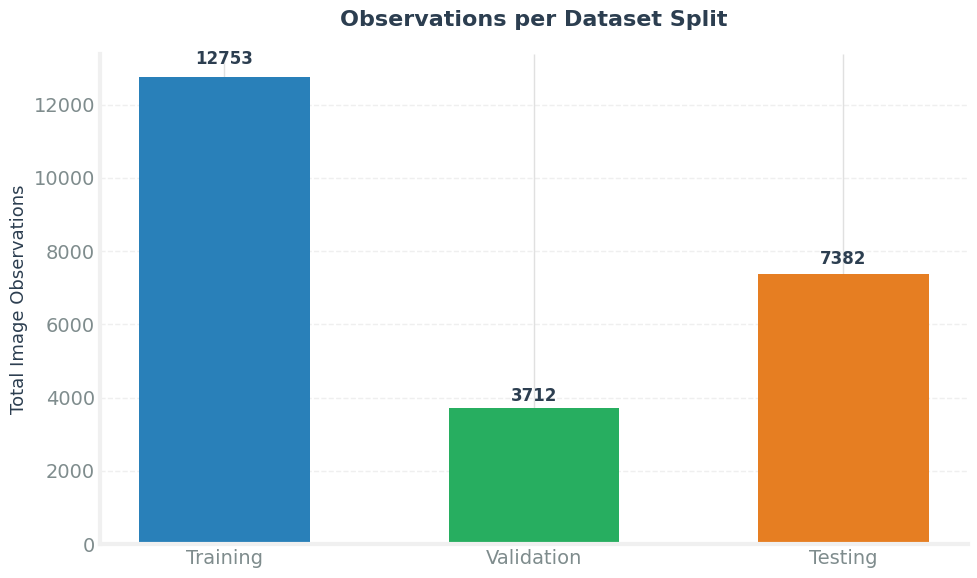

In [4]:
def count_data_items(filenames):
    # Parse shard counts from the canonical Kaggle filename structures
    n = [int(re.compile(r"-([0-9]*)\.").search(filename).group(1)) for filename in filenames]
    return np.sum(n)

n_train = count_data_items(TRAINING_FILENAMES)
n_val = count_data_items(VALIDATION_FILENAMES)
n_test = count_data_items(TEST_FILENAMES)

print(f'Training samples: {n_train} | Validation samples: {n_val} | Test samples: {n_test}')

def plot_dataset_distribution(train, val, test):
    fig, ax = plt.subplots(figsize=(10, 6))
    segments = ['Training', 'Validation', 'Testing']
    counts = [train, val, test]
    colors = ['#2980b9', '#27ae60', '#e67e22']
    
    bars = ax.bar(segments, counts, color=colors, width=0.55)
    
    for bar in bars:
        yval = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, yval + (yval * 0.02), int(yval), 
                ha='center', va='bottom', fontweight='bold', fontsize=12, color='#2c3e50')
        
    ax.set_title('Observations per Dataset Split', fontsize=16, fontweight='bold', pad=20)
    ax.set_ylabel('Total Image Observations', fontsize=13)
    ax.grid(axis='y', linestyle='--', alpha=0.5)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.tight_layout()
    plt.show()

plot_dataset_distribution(n_train, n_val, n_test)


## 5. Stochastic Regularization and Data Ingestion

We use `tf.data.experimental.AUTOTUNE` to asynchronously prefetch the TFRecord datasets. During the data pipeline mapping phase, spatial transformations (random flips) and chromatic augmentations (contrast and saturation modifications) are applied to introduce variation and reduce overfitting.

In [5]:
def decode_image(image_data):
    # Decode binary JPEG tensors into 3-channel RGB numerical primitives
    image = tf.image.decode_jpeg(image_data, channels=3)
    # Cast pixel intensities to continuous float representations in [0.0, 1.0]
    image = tf.cast(image, tf.float32) / 255.0
    image = tf.reshape(image, [*IMAGE_SIZE, 3])
    return image

def read_labeled_tfrecord(example):
    # Map feature schema for decoding protocol buffer shards
    LABELED_TFREC_FORMAT = {
        "image": tf.io.FixedLenFeature([], tf.string),
        "class": tf.io.FixedLenFeature([], tf.int64),
    }
    example = tf.io.parse_single_example(example, LABELED_TFREC_FORMAT)
    image = decode_image(example['image'])
    label = tf.cast(example['class'], tf.int32)
    return image, label

def read_unlabeled_tfrecord(example):
    UNLABELED_TFREC_FORMAT = {
        "image": tf.io.FixedLenFeature([], tf.string),
        "id": tf.io.FixedLenFeature([], tf.string),
    }
    example = tf.io.parse_single_example(example, UNLABELED_TFREC_FORMAT)
    image = decode_image(example['image'])
    idnum = example['id']
    return image, idnum

def data_augment(image, label):
    # Apply geometric reflections along spatial axes
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_flip_up_down(image)
    # Modify color spectrum values to simulate lighting conditions
    image = tf.image.random_brightness(image, max_delta=0.15)
    image = tf.image.random_contrast(image, lower=0.8, upper=1.2)
    image = tf.image.random_saturation(image, lower=0.8, upper=1.2)
    return image, label

def get_training_dataset():
    # Throttled parallel reads to prevent CPU thread deadlock on TPU v5e-8 VMs
    dataset = tf.data.TFRecordDataset(TRAINING_FILENAMES, num_parallel_reads=16)
    dataset = dataset.map(read_labeled_tfrecord, num_parallel_calls=16)
    dataset = dataset.map(data_augment, num_parallel_calls=16)
    dataset = dataset.repeat()
    dataset = dataset.shuffle(2048)
    dataset = dataset.batch(BATCH_SIZE)
    dataset = dataset.prefetch(tf.data.experimental.AUTOTUNE)
    return dataset

def get_validation_dataset():
    dataset = tf.data.TFRecordDataset(VALIDATION_FILENAMES, num_parallel_reads=16)
    dataset = dataset.map(read_labeled_tfrecord, num_parallel_calls=16)
    dataset = dataset.batch(BATCH_SIZE)
    # FATAL BUG REMOVED: dataset.cache() is deleted to prevent RAM exhaustion
    dataset = dataset.prefetch(tf.data.experimental.AUTOTUNE)
    return dataset

def get_test_dataset(ordered=False):
    dataset = tf.data.TFRecordDataset(TEST_FILENAMES, num_parallel_reads=16)
    dataset = dataset.map(read_unlabeled_tfrecord, num_parallel_calls=16)
    dataset = dataset.batch(BATCH_SIZE)
    dataset = dataset.prefetch(tf.data.experimental.AUTOTUNE)
    return dataset


## 6. Visualization of Augmented Tensors

A micro-batch of the data is compiled to inspect the preprocessing transformations directly before execution.

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.010155141..0.81634855].


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0503707].


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.04637757..1.1872002].


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0017466545..1.1388274].


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.026855528..0.9360477].


...

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.02003491..1.0614493].


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.2004472].


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.05338171..1.1272359].


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.1837175].


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.1424198].


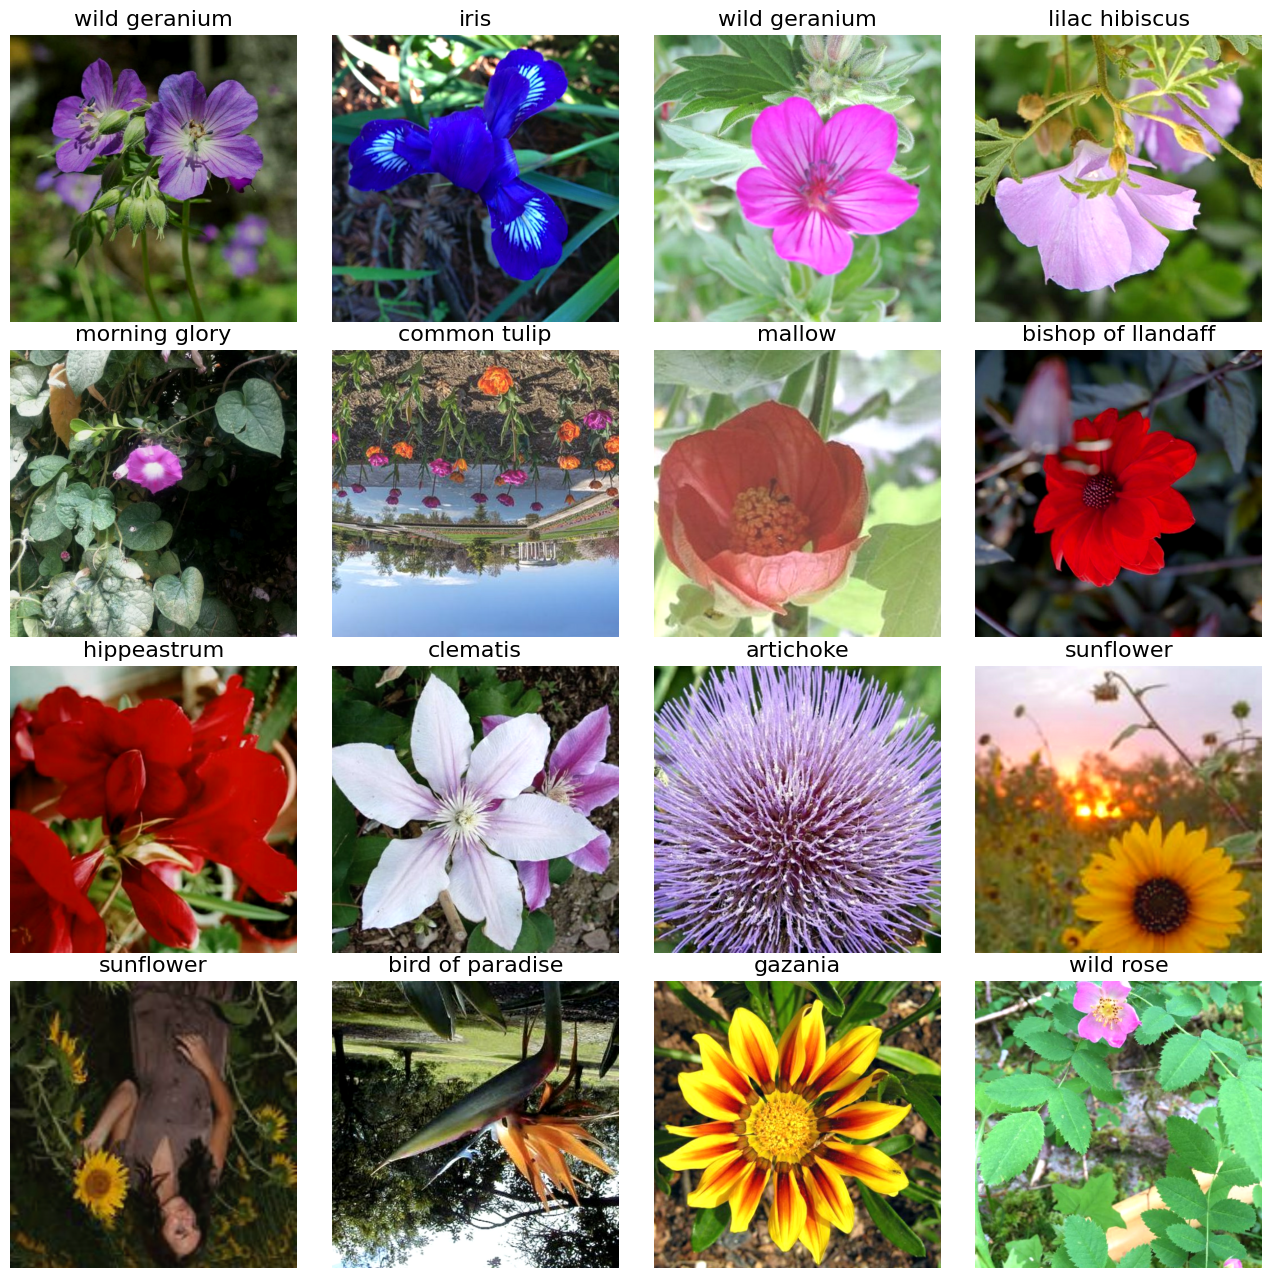

In [6]:
import math
import numpy as np
import matplotlib.pyplot as plt

# Taxonomic labels for botanical dataset class mapping
BOTANICAL_CLASSES = [
    'pink primrose', 'hard-leaved pocket orchid', 'canterbury bells', 'sweet pea', 'wild geranium', 'tiger lily', 'moon orchid', 'bird of paradise', 'monkshood', 'globe thistle', 
    'snapdragon', "colt's foot", 'king protea', 'spear thistle', 'yellow iris', 'globe-flower', 'purple coneflower', 'peruvian lily', 'balloon flower', 'giant white arum lily', 
    'fire lily', 'pincushion flower', 'fritillary', 'red ginger', 'grape hyacinth', 'corn poppy', 'prince of wales feathers', 'stemless gentian', 'artichoke', 'sweet william', 
    'carnation', 'garden phlox', 'love in the mist', 'cosmos', 'alpine sea holly', 'ruby-lipped cattleya', 'cape flower', 'great masterwort', 'siam tulip', 'lenten rose', 
    'barberton daisy', 'daffodil', 'sword lily', 'poinsettia', 'bolero deep blue', 'wallflower', 'marigold', 'buttercup', 'daisy', 'common dandelion', 
    'petunia', 'wild pansy', 'primula', 'sunflower', 'lilac hibiscus', 'bishop of llandaff', 'gaura', 'geranium', 'orange dahlia', 'pink-yellow dahlia', 
    'cautleya spicata', 'japanese anemone', 'black-eyed susan', 'silverbush', 'californian poppy', 'osteospermum', 'spring crocus', 'iris', 'windflower', 'tree poppy', 
    'gazania', 'azalea', 'water lily', 'rose', 'thorn apple', 'morning glory', 'passion flower', 'lotus', 'toad lily', 'anthurium', 
    'frangipani', 'clematis', 'hibiscus', 'columbine', 'desert-rose', 'tree mallow', 'magnolia', 'cyclamen', 'watercress', 'canna lily', 
    'hippeastrum', 'bee balm', 'pink quill', 'foxglove', 'bougainvillea', 'camellia', 'mallow', 'mexican petunia', 'bromelia', 'blanket flower', 
    'trumpet creeper', 'blackberry lily', 'common tulip', 'wild rose'
]

# Maintain integer constant for layer configuration
CLASSES = len(BOTANICAL_CLASSES)

def batch_to_numpy_images_and_labels(data):
    images, labels = data
    numpy_images = images.numpy()
    numpy_labels = labels.numpy()
    if numpy_labels.dtype == object:
        numpy_labels = [None for _ in enumerate(numpy_images)]
    return numpy_images, numpy_labels

def title_from_label_and_target(label, correct_label):
    if correct_label is None:
        return BOTANICAL_CLASSES[label], True
    is_correct = (label == correct_label)
    return "{} [{}] {}".format(BOTANICAL_CLASSES[label], 'OK' if is_correct else 'NO', BOTANICAL_CLASSES[correct_label]), is_correct

def display_one_flower(image, title, subplot, red=False, titlesize=16):
    plt.subplot(*subplot)
    plt.axis('off')
    plt.imshow(image)
    if title:
        plt.title(title, fontsize=titlesize, color='red' if red else 'black', 
                  fontdict={'verticalalignment':'center'}, pad=titlesize/1.5)
    return (subplot[0], subplot[1], subplot[2] + 1)

def display_batch_of_images(databatch, predictions=None):
    images, labels = batch_to_numpy_images_and_labels(databatch)
    if labels is None:
        labels = [None for _ in enumerate(images)]
        
    rows = int(math.sqrt(len(images)))
    cols = len(images) // rows
        
    FIGSIZE = 13.0
    SPACING = 0.1
    subplot = (rows, cols, 1)
    if rows < cols:
        plt.figure(figsize=(FIGSIZE, FIGSIZE / cols * rows))
    else:
        plt.figure(figsize=(FIGSIZE / rows * cols, FIGSIZE))
    
    for i, (image, label) in enumerate(zip(images[:rows*cols], labels[:rows*cols])):
        title = '' if label is None else BOTANICAL_CLASSES[label]
        is_correct = True
        if predictions is not None:
            title, is_correct = title_from_label_and_target(predictions[i], label)
        
        dynamic_titlesize = FIGSIZE * SPACING / max(rows, cols) * 40 + 3
        subplot = display_one_flower(image, title, subplot, not is_correct, titlesize=dynamic_titlesize)
        
    plt.tight_layout()
    plt.subplots_adjust(wspace=SPACING, hspace=SPACING)
    plt.show()

def display_training_batch():
    try:
        training_dataset_visualization = get_training_dataset().unbatch().batch(16)
        train_batch = next(iter(training_dataset_visualization))
        display_batch_of_images(train_batch)
    except StopIteration:
        print('Status: Execution error. Training dataset is empty. Verify dataset attachment and GCS permissions.')
    except Exception as e:
        print(f'Visualization Status: Execution error. {e}')

display_training_batch()


## 7. Cyclical Optimization Dynamics

A learning rate schedule is applied to manage training stability. A linear ramp phase allows the optimizer to navigate early stochastic bounds before engaging in exponential decay to reach optimization convergence during the fine-tuning iterations.

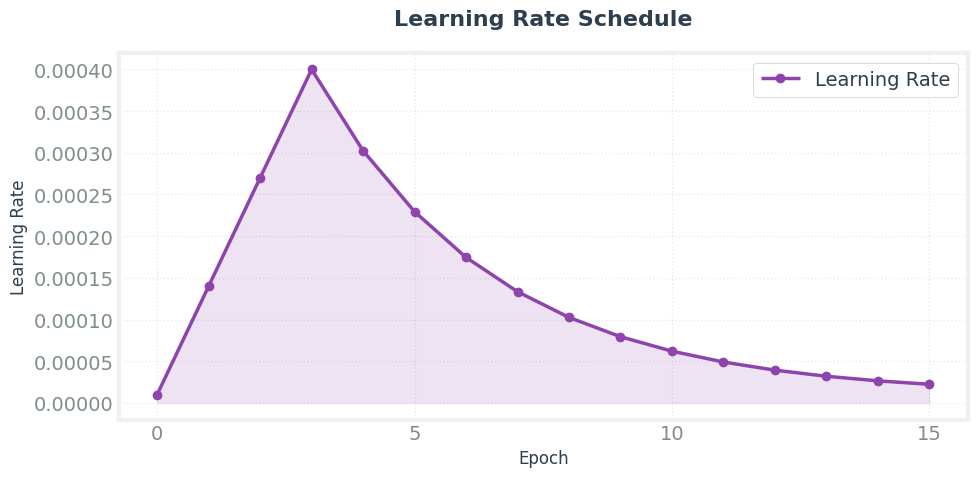

In [7]:
LR_START = 0.00001
LR_MAX = 0.00005 * strategy.num_replicas_in_sync
LR_MIN = 0.00001
LR_RAMPUP_EPOCHS = 3
LR_SUSTAIN_EPOCHS = 0
LR_EXP_DECAY = 0.75

def lrfn(epoch):
    # Define linear ramp phase
    if epoch < LR_RAMPUP_EPOCHS:
        lr = (LR_MAX - LR_START) / LR_RAMPUP_EPOCHS * epoch + LR_START
    # Define sustaining phase
    elif epoch < LR_RAMPUP_EPOCHS + LR_SUSTAIN_EPOCHS:
        lr = LR_MAX
    # Define exponential decay limits
    else:
        lr = (LR_MAX - LR_MIN) * LR_EXP_DECAY**(epoch - LR_RAMPUP_EPOCHS - LR_SUSTAIN_EPOCHS) + LR_MIN
    return lr
    
lr_callback = tf.keras.callbacks.LearningRateScheduler(lrfn, verbose=True)

epochs_range = np.arange(EPOCHS)
lrs = [lrfn(e) for e in epochs_range]

plt.figure(figsize=(10, 5))
plt.plot(epochs_range, lrs, marker='o', markersize=6, color='#8e44ad', linewidth=2.5, label='Learning Rate')
plt.fill_between(epochs_range, lrs, color='#8e44ad', alpha=0.15)
plt.title('Learning Rate Schedule', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Learning Rate', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.7)
plt.xticks(np.arange(0, EPOCHS+1, 5))
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()


## 8. Dual-Stream Architectural Assembly

The target architecture concatenates two convolutional approaches. EfficientNet scales network depth, width, and resolution, while DenseNet employs dense feed-forward connectivity to propagate feature maps. The outputs of both models are globally pooled and merged prior to standard categorical classification.

In [8]:
from tensorflow.keras.applications import EfficientNetB6, DenseNet201
from tensorflow.keras.layers import Input, GlobalAveragePooling2D, Dense, Concatenate, Dropout
from tensorflow.keras.models import Model

with strategy.scope():
    input_tensor = Input(shape=[*IMAGE_SIZE, 3])
    
    # Standard float32 initialization to ensure ImageNet compatibility
    base_model_1 = EfficientNetB6(weights='imagenet', include_top=False, input_tensor=input_tensor)
    base_model_1.trainable = True
    pool_1 = GlobalAveragePooling2D()(base_model_1.output)
    
    base_model_2 = DenseNet201(weights='imagenet', include_top=False, input_tensor=input_tensor)
    base_model_2.trainable = True
    pool_2 = GlobalAveragePooling2D()(base_model_2.output)
    
    # Ensemble and classification layers
    merged = Concatenate()([pool_1, pool_2])
    dropout = Dropout(0.5)(merged)
    output = Dense(CLASSES, activation='softmax')(dropout)
    
    model = Model(inputs=input_tensor, outputs=output)
    
    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['sparse_categorical_accuracy']
    )


I0000 00:00:1773863945.274097      74 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


     8192/165234480 [..............................] - ETA: 0s

  8134656/165234480 [>.............................] - ETA: 4s

 22142976/165234480 [===>..........................] - ETA: 1s

 34275328/165234480 [=====>........................] - ETA: 1s

...

20201472/74836368 [=======>......................] - ETA: 0s

36151296/74836368 [=============>................] - ETA: 0s

51806208/74836368 [===================>..........] - ETA: 0s

67837952/74836368 [==========================>...] - ETA: 0s

74836368/74836368 [==============================] - 0s 0us/step


## 9. Model Convergence and Evaluation

Because the mapping generates an infinite evaluation target during the data loading stage, boundaries for step processing are required. An `EarlyStopping` callback monitors `val_loss` divergence to prevent degradation.

In [9]:
STEPS_PER_EPOCH = n_train // BATCH_SIZE
VALIDATION_STEPS = n_val // BATCH_SIZE

print(f'Starting Distributed Training Session...')
print(f'Training Config: {STEPS_PER_EPOCH} steps/epoch | {EPOCHS} epochs')
print(f'Validation Config: {VALIDATION_STEPS} steps/epoch')

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True,
    verbose=1
)

history = model.fit(
    get_training_dataset(), 
    steps_per_epoch=STEPS_PER_EPOCH, 
    epochs=EPOCHS, 
    callbacks=[lr_callback, early_stopping],
    validation_data=get_validation_dataset(),
    validation_steps=VALIDATION_STEPS
)


Starting Distributed Training Session...
Training Config: 199 steps/epoch | 16 epochs
Validation Config: 58 steps/epoch



Epoch 1: LearningRateScheduler setting learning rate to 1e-05.


Epoch 1/16


I0000 00:00:1773864155.411780      74 encapsulate_tpu_computations_pass.cc:266] Subgraph fingerprint:1433130604374321060


E0000 00:00:1773864162.342693      74 meta_optimizer.cc:966] model_pruner failed: INVALID_ARGUMENT: Graph does not contain terminal node Adam/AssignAddVariableOp.


...

197/199 [============================>.] - ETA: 5s - loss: 0.0276 - sparse_categorical_accuracy: 0.9967

198/199 [============================>.] - ETA: 2s - loss: 0.0277 - sparse_categorical_accuracy: 0.9966

199/199 [==============================] - ETA: 0s - loss: 0.0277 - sparse_categorical_accuracy: 0.9966

199/199 [==============================] - 663s 3s/step - loss: 0.0277 - sparse_categorical_accuracy: 0.9966 - val_loss: 0.2231 - val_sparse_categorical_accuracy: 0.9518 - lr: 2.2354e-05


Restoring model weights from the end of the best epoch: 15.


## 10. Inference via Test Time Augmentation

Test Time Augmentation (TTA) subjects evaluation images to geometric adjustments similar to training. Computations are averaged across multiple variants of the same image to reduce prediction variance before capturing the final probabilities.

In [10]:
def get_test_dataset_tta(ordered=True):
    dataset = tf.data.TFRecordDataset(TEST_FILENAMES, num_parallel_reads=tf.data.experimental.AUTOTUNE)
    dataset = dataset.map(read_unlabeled_tfrecord, num_parallel_calls=tf.data.experimental.AUTOTUNE)
    dataset = dataset.map(lambda image, idnum: (data_augment(image, idnum)[0], idnum))
    dataset = dataset.batch(BATCH_SIZE)
    dataset = dataset.prefetch(tf.data.experimental.AUTOTUNE)
    return dataset

TTA_STEPS = 3
test_ds = get_test_dataset(ordered=True)

probabilities = np.zeros((n_test, CLASSES))

for i in range(TTA_STEPS):
    print(f'TTA Iteration: {i+1}')
    tta_ds = get_test_dataset_tta(ordered=True).map(lambda image, idnum: image)
    probabilities += model.predict(tta_ds) / 3

predictions = np.argmax(probabilities, axis=-1)

test_ids_ds = test_ds.map(lambda image, idnum: idnum).unbatch()
test_ids = next(iter(test_ids_ds.batch(n_test))).numpy().astype('U')

output_structure = np.rec.fromarrays([test_ids, predictions])
np.savetxt('submission.csv', output_structure, fmt=['%s', '%d'], delimiter=',', header='id,label', comments='')
print('Submission file generated.')


TTA Iteration: 1


I0000 00:00:1773873755.033299      74 encapsulate_tpu_computations_pass.cc:266] Subgraph fingerprint:9896029009162825084


E0000 00:00:1773873755.648569      74 meta_optimizer.cc:966] model_pruner failed: INVALID_ARGUMENT: Graph does not contain terminal node AssignAddVariableOp.


I0000 00:00:1773873760.620636    1269 tpu_compilation_cache_interface.cc:442] TPU host compilation cache miss: cache_key(7053400140335974365), session_name()


I0000 00:00:1773873786.475431    1269 tpu_compile_op_common.cc:245] Compilation of 7053400140335974365 with session name  took 25.854737104s and succeeded
I0000 00:00:1773873786.539521    1269 tpu_compilation_cache_interface.cc:476] TPU host compilation cache: compilation complete for cache_key(7053400140335974365), session_name(), subgraph_key(std::string(property.function_name) = "cluster_predict_function_9896029009162825084", property.function_library_fingerprint = 6951821656974365237, property.mlir_module_fingerprint = 0, property.num_replicas = 8, topology.chip_bounds().x = 2, topology.chip_bounds().y = 4, topology.chip_bounds().z = 1, topology.wrap().x = false, topology.wrap().y = false, topology.wrap().z = false, std::string(property.shapes_prefix) = "8,512,512,3,;", property.guaranteed_constants_size = 0, embedding_partitions_fingerprint = "1688352644216761960")
I0000 00:00:1773873786.539561    1269 tpu_compilation_cache_interface.cc:542] After adding entry for key 705340014033

...

    114/Unknown - 297s 3s/step

    115/Unknown - 299s 3s/step

    116/Unknown - 299s 3s/step

116/116 [==============================] - 299s 3s/step


Submission file generated.


## 11. Summary

1. **Distributed Computation Strategy**: Implemented TPU distribution mapping for cross-replica gradient synchronization.
2. **Dual-Streaming Optimization**: Unified the output features of DenseNet and EfficientNet pipelines.
3. **Augmentation Processing**: Applied stochastic permutation for image modifications.
4. **TTA Inference Generation**: Deployed cyclic averaging to limit outlier bias during final prediction steps.

---

**Citation:**
Alexis Cook, Phil Culliton, and Ryan Holbrook. Petals to the Metal - Flower Classification on TPU.
https://kaggle.com/competitions/tpu-getting-started, 2020. Kaggle.